# Interpretabilidad del modelo — Riesgo de retraso en el pago

## Objetivo del notebook

El objetivo de este notebook es interpretar el comportamiento de la regresión logística seleccionada durante la fase de baseline.

El modelo seleccionado corresponde al **Modelo C**, formado por:

- características de la factura actual;
- contexto temporal;
- histórico comercial del cliente;
- comportamiento histórico de pago;
- comportamiento reciente;
- variables relativas al importe;
- indicadores de disponibilidad de histórico.

El Modelo C fue seleccionado porque mantiene una capacidad predictiva equivalente o ligeramente superior al modelo completo utilizando un conjunto más reducido de variables.

Sobre el conjunto de validation obtuvo aproximadamente:

- ROC-AUC = 0,904;
- PR-AUC = 0,802;
- Recall ≈ 0,83 con threshold 0,50.

Además, durante el análisis de threshold se identificó `0.40` como candidato operativo provisional, ya que permite mantener un Recall superior al 90 % con menos falsas alarmas que el threshold que maximiza F2.

## Preguntas que se quieren responder

La interpretabilidad del modelo debe permitir responder:

1. ¿Qué variables están asociadas con un mayor riesgo de retraso?
2. ¿Qué variables están asociadas con un menor riesgo?
3. ¿El histórico de pago del cliente aparece realmente entre las variables más relevantes?
4. ¿Las relaciones aprendidas por el modelo tienen sentido empresarial?
5. ¿Existen variables redundantes o con efectos difíciles de justificar?
6. ¿El comportamiento del modelo es suficientemente interpretable como para utilizarlo como baseline de negocio?

## Alcance

La interpretación se realizará sobre la regresión logística entrenada exclusivamente con el conjunto de train.

El conjunto de validation podrá utilizarse para comprobar el comportamiento del modelo, pero el conjunto de test continuará completamente reservado.

No se utilizará test para:

- interpretar coeficientes;
- seleccionar variables;
- modificar el modelo;
- ajustar el threshold.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
)

from sklearn.inspection import permutation_importance

In [2]:
PROJECT_ROOT = Path("..")

GOLD_DIR = (
    PROJECT_ROOT
    / "data"
    / "gold"
)

GOLD_FILE = (
    GOLD_DIR
    / "gold_invoice_risk.parquet"
)

print(
    GOLD_FILE.resolve()
)

C:\Users\jesus\OneDrive\Documents\Evolve Data Science\portfolio\sistema_predictivo_tesoreria_y_riesgo_de_impago\data\gold\gold_invoice_risk.parquet


In [3]:
df = pd.read_parquet(
    GOLD_FILE
)

print(
    f"Filas: {df.shape[0]:,}"
)

print(
    f"Columnas: {df.shape[1]}"
)

display(
    df.head()
)

Filas: 2,466
Columnas: 48


,invoice_id,customer_id,invoice_date,due_date,invoice_amount,log_invoice_amount,paperless_bill,country_code,invoice_year,invoice_month,...,amount_diff_vs_previous_avg,open_amount_vs_current_invoice,overdue_amount_vs_current_invoice,is_new_customer,has_payment_history,has_3_payment_history,has_5_payment_history,has_open_invoices,has_overdue_invoices,late_payment
0,280670965,3993-QUNVJ,2012-01-03,2012-02-02,50.39,3.939444,PAPER,770,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,0
1,5133177585,6708-DPYTF,2012-01-03,2012-02-02,55.37,4.031937,PAPER,391,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,1
2,5928070131,1604-LIFKX,2012-01-03,2012-02-02,97.60,4.591071,PAPER,818,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,1
3,6050714721,8887-NCUZC,2012-01-03,2012-02-02,15.99,2.832625,PAPER,818,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,1
4,6393629835,5164-VMYWJ,2012-01-03,2012-02-02,71.33,4.281239,PAPER,406,2012,1,...,NaN,0.0,0.0,1,0,0,0,0,0,0


## 1. Validación del dataset de entrada

Este notebook parte directamente de `gold_invoice_risk.parquet`.

Antes de reconstruir el modelo se comprobará que el dataset coincide con el utilizado durante el notebook de baseline.

La interpretabilidad únicamente será válida si se reproduce exactamente:

- el mismo dataset;
- la misma variable objetivo;
- la misma división temporal;
- el mismo conjunto de features;
- el mismo pipeline de preprocesamiento;
- la misma regresión logística.

El primer objetivo será por tanto reproducir las métricas obtenidas anteriormente antes de analizar los coeficientes.

### Checks basicos

In [4]:
checks = pd.Series({
    "rows": len(df),

    "columns": df.shape[1],

    "duplicated_invoice_id": (
        df["invoice_id"]
        .duplicated()
        .sum()
    ),

    "missing_invoice_date": (
        df["invoice_date"]
        .isna()
        .sum()
    ),

    "missing_target": (
        df["late_payment"]
        .isna()
        .sum()
    ),

    "positive_cases": (
        df["late_payment"]
        .sum()
    ),

    "positive_rate_pct": (
        df["late_payment"]
        .mean()
        * 100
    ),

    "min_date": (
        df["invoice_date"]
        .min()
    ),

    "max_date": (
        df["invoice_date"]
        .max()
    ),
})

display(checks)

assert len(df) == 2466

assert df["invoice_id"].is_unique

assert df["invoice_date"].notna().all()

assert df["late_payment"].notna().all()

assert (
    df["late_payment"].sum()
    == 877
)

assert set(
    df["late_payment"].unique()
).issubset({0, 1})

print(
    "✓ Dataset Gold validado."
)

rows                                    2466
columns                                   48
duplicated_invoice_id                      0
missing_invoice_date                       0
missing_target                             0
positive_cases                           877
positive_rate_pct                  35.563666
min_date                 2012-01-03 00:00:00
max_date                 2013-12-02 00:00:00
dtype: object

✓ Dataset Gold validado.


### Validamos Gold

In [5]:
expected_has_overdue = (
    df["overdue_invoice_count_at_issue"]
    > 0
).astype("int8")

assert (
    df["has_overdue_invoices"]
    == expected_has_overdue
).all()

assert (
    df.loc[
        df[
            "overdue_invoice_count_at_issue"
        ] == 0,
        "oldest_overdue_days_at_issue"
    ] == 0
).all()

assert (
    df[
        "oldest_overdue_days_at_issue"
    ]
    .notna()
    .all()
)

print(
    "✓ Se está utilizando la versión "
    "actualizada del Gold."
)

✓ Se está utilizando la versión actualizada del Gold.


### Definir identificadores y target

In [6]:
identifier_columns = [
    "invoice_id",
    "customer_id",
    "invoice_date",
    "due_date",
]

target_column = (
    "late_payment"
)

### Definir las features del Modelo C

In [7]:
invoice_features = [
    "invoice_amount",
    "log_invoice_amount",
    "paperless_bill",
    "country_code",
]

temporal_features = [
    "invoice_year",
    "invoice_month",
    "invoice_quarter",
    "invoice_weekday",
    "is_month_start",
    "is_month_end",
    "days_since_dataset_start",
]

customer_history_features = [
    # Histórico comercial
    "previous_issued_count",
    "previous_avg_invoice_amount",
    "previous_median_invoice_amount",
    "days_since_previous_invoice",

    # Histórico de pagos conocido
    "previous_settled_count",
    "previous_late_count",
    "previous_late_rate",
    "previous_avg_delay",
    "previous_median_delay",
    "previous_max_delay",
    "last_payment_delay",
    "days_since_last_payment",

    # Comportamiento reciente
    "last_3_late_rate",
    "last_3_avg_delay",
    "last_5_late_rate",
    "last_5_avg_delay",

    # Importe relativo
    "amount_vs_previous_avg",
    "amount_vs_previous_median",
    "amount_diff_vs_previous_avg",

    # Disponibilidad de histórico
    "is_new_customer",
    "has_payment_history",
    "has_3_payment_history",
    "has_5_payment_history",
]

model_c_features = (
    invoice_features
    + temporal_features
    + customer_history_features
)

print(
    f"Features Modelo C: "
    f"{len(model_c_features)}"
)

Features Modelo C: 34


### Validar Modelo C

In [8]:
assert len(
    model_c_features
) == 34

missing_features = [
    col
    for col in model_c_features
    if col not in df.columns
]

assert not missing_features, (
    f"Faltan features: "
    f"{missing_features}"
)

print(
    "✓ Las 34 features del Modelo C "
    "están disponibles."
)

✓ Las 34 features del Modelo C están disponibles.


## 2. Reconstrucción del split temporal

La interpretación debe realizarse sobre exactamente el mismo modelo entrenado durante la fase de baseline.

Por ello se reproducirá la división temporal utilizada anteriormente.

La división utiliza fechas únicas para impedir que facturas emitidas el mismo día aparezcan en conjuntos diferentes.

Se mantiene aproximadamente:

- 70 % del período para train;
- 15 % para validation;
- 15 % para test.

El conjunto de test se reconstruye únicamente para mantener la estructura del proyecto, pero no será utilizado durante este notebook.

### Reconstruir split

In [9]:
unique_dates = np.sort(
    df["invoice_date"]
    .dropna()
    .unique()
)

train_cut_index = int(
    len(unique_dates) * 0.70
)

validation_cut_index = int(
    len(unique_dates) * 0.85
)

train_cutoff = (
    unique_dates[
        train_cut_index
    ]
)

validation_cutoff = (
    unique_dates[
        validation_cut_index
    ]
)

train_df = df[
    df["invoice_date"]
    < train_cutoff
].copy()

validation_df = df[
    (
        df["invoice_date"]
        >= train_cutoff
    )
    &
    (
        df["invoice_date"]
        < validation_cutoff
    )
].copy()

test_df = df[
    df["invoice_date"]
    >= validation_cutoff
].copy()

### Validar split

In [10]:
split_summary = []

for name, subset in {
    "train": train_df,
    "validation": validation_df,
    "test": test_df,
}.items():

    split_summary.append({
        "dataset": name,

        "rows": len(subset),

        "start_date": (
            subset["invoice_date"]
            .min()
        ),

        "end_date": (
            subset["invoice_date"]
            .max()
        ),

        "positive_cases": (
            subset[
                "late_payment"
            ].sum()
        ),

        "positive_rate": (
            subset[
                "late_payment"
            ].mean()
        ),
    })

split_summary = pd.DataFrame(
    split_summary
)

split_summary

,dataset,rows,start_date,end_date,positive_cases,positive_rate
0,train,1719,2012-01-03,2013-05-04,656,0.381617
1,validation,381,2013-05-05,2013-08-19,124,0.325459
2,test,366,2013-08-20,2013-12-02,97,0.265027


### Separar `X` e `y`

In [11]:
X_train = (
    train_df[
        model_c_features
    ]
    .copy()
)

y_train = (
    train_df[
        target_column
    ]
    .copy()
)

X_validation = (
    validation_df[
        model_c_features
    ]
    .copy()
)

y_validation = (
    validation_df[
        target_column
    ]
    .copy()
)

## 3. Reconstrucción del pipeline del Modelo C

La regresión logística debe reconstruirse utilizando exactamente el mismo preprocesamiento que durante la fase de baseline.

### Variables numéricas

Se aplica:

1. imputación mediante mediana;
2. estandarización mediante `StandardScaler`.

La estandarización es especialmente importante para la interpretación de los coeficientes, ya que las variables numéricas quedarán expresadas aproximadamente en una escala comparable.

### Variables categóricas

Se aplica:

1. imputación mediante la categoría más frecuente;
2. One-Hot Encoding.

Las categorías generadas por One-Hot Encoding tendrán coeficientes propios dentro de la regresión logística.

Todas las transformaciones se ajustan exclusivamente utilizando train.

### Definir categoricas y numericas

In [12]:
categorical_features = [
    "paperless_bill",
    "country_code",
    "invoice_month",
    "invoice_quarter",
    "invoice_weekday",
]

numeric_features = [
    col
    for col in model_c_features
    if col not in categorical_features
]

print(
    f"Numéricas: "
    f"{len(numeric_features)}"
)

print(
    f"Categóricas originales: "
    f"{len(categorical_features)}"
)

Numéricas: 29
Categóricas originales: 5


### Construir pipelines

In [13]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        ),
    ]
)

### Column transformer

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            numeric_features,
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features,
        ),
    ]
)

### Reconstruir regresion logistica

In [15]:
logistic_model_c = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                random_state=42,
            )
        ),
    ]
)

### Entrenar

In [16]:
logistic_model_c.fit(
    X_train,
    y_train
)

print(
    "✓ Modelo C reconstruido "
    "y entrenado."
)

✓ Modelo C reconstruido y entrenado.


### Funcion de evaluacion minima

In [17]:
def evaluate_model(
    model,
    X,
    y
):
    y_pred = model.predict(X)

    y_prob = (
        model
        .predict_proba(X)[:, 1]
    )

    return pd.Series({
        "accuracy": (
            accuracy_score(
                y,
                y_pred
            )
        ),

        "balanced_accuracy": (
            balanced_accuracy_score(
                y,
                y_pred
            )
        ),

        "precision": (
            precision_score(
                y,
                y_pred,
                zero_division=0
            )
        ),

        "recall": (
            recall_score(
                y,
                y_pred,
                zero_division=0
            )
        ),

        "f1": (
            f1_score(
                y,
                y_pred,
                zero_division=0
            )
        ),

        "f2": (
            fbeta_score(
                y,
                y_pred,
                beta=2,
                zero_division=0
            )
        ),

        "roc_auc": (
            roc_auc_score(
                y,
                y_prob
            )
        ),

        "pr_auc": (
            average_precision_score(
                y,
                y_prob
            )
        ),
    })

### Reproducibilidad de metricas

In [18]:
train_metrics = (
    evaluate_model(
        logistic_model_c,
        X_train,
        y_train
    )
)

validation_metrics = (
    evaluate_model(
        logistic_model_c,
        X_validation,
        y_validation
    )
)

reproducibility_results = pd.DataFrame({
    "train": train_metrics,
    "validation": validation_metrics,
}).T

reproducibility_results

,accuracy,balanced_accuracy,precision,recall,f1,f2,roc_auc,pr_auc
train,0.788249,0.766627,0.745791,0.675305,0.708800,0.688316,0.867431,0.810416
validation,0.834646,0.833611,0.710345,0.830645,0.765799,0.803432,0.904387,0.801798


### Checks de reproducibilidad

In [19]:
assert np.isclose(
    validation_metrics[
        "roc_auc"
    ],
    0.904,
    atol=0.01
)

assert np.isclose(
    validation_metrics[
        "pr_auc"
    ],
    0.802,
    atol=0.01
)

print(
    "✓ El Modelo C reproduce "
    "los resultados del baseline."
)

✓ El Modelo C reproduce los resultados del baseline.


## Modelo reproducido

El Modelo C ha sido reconstruido utilizando exclusivamente el dataset Gold y las decisiones documentadas durante la fase de baseline.

Las métricas obtenidas son coherentes con las observadas anteriormente, por lo que el modelo puede considerarse reproducido correctamente.

A partir de este punto comienza el análisis de interpretabilidad.

El siguiente objetivo será transformar los coeficientes internos de la regresión logística en una tabla interpretable que permita identificar:

- variables asociadas con un aumento del riesgo;
- variables asociadas con una reducción del riesgo;
- magnitud relativa de las asociaciones;
- odds ratios;
- posibles efectos redundantes o difíciles de justificar.

Debe recordarse que los coeficientes de una regresión logística representan asociaciones condicionadas al resto de variables incluidas en el modelo y no implican relaciones causales.

## 4. Interpretación de los coeficientes

La regresión logística modela la probabilidad de retraso mediante una combinación lineal de las features transformadas.

Cada coeficiente indica cómo cambia el **log-odds** de pertenecer a la clase positiva (`late_payment = 1`) cuando aumenta una variable, manteniendo constantes las demás.

En términos generales:

- coeficiente positivo → asociado con mayor riesgo de retraso;
- coeficiente negativo → asociado con menor riesgo;
- coeficiente cercano a cero → asociación lineal reducida dentro del modelo.

Para facilitar la interpretación también se calculará el **odds ratio**:

`odds_ratio = exp(coeficiente)`

De forma aproximada:

- `odds_ratio > 1` → aumenta las odds de retraso;
- `odds_ratio < 1` → reduce las odds de retraso;
- `odds_ratio ≈ 1` → efecto pequeño.

### Precaución con las variables numéricas

Las variables numéricas fueron estandarizadas mediante `StandardScaler`.

Por tanto, en estas variables el coeficiente representa aproximadamente el efecto asociado a un incremento de **una desviación estándar**, no necesariamente a una unidad original.

### Precaución con variables categóricas

Las variables categóricas fueron transformadas mediante One-Hot Encoding sin eliminar una categoría de referencia.

Por este motivo sus coeficientes pueden utilizarse para estudiar dirección y relevancia relativa dentro del modelo, pero no deben interpretarse todavía como odds ratios clásicos respecto a una categoría base concreta.

Posteriormente, si fuese necesario, podrá construirse una versión específica de interpretación categórica con una categoría de referencia explícita.

Finalmente, los coeficientes describen **asociaciones predictivas condicionadas al resto de variables** y no relaciones causales.

### Extraer preprocesador y clasificador

In [20]:
preprocessor_fitted = (
    logistic_model_c
    .named_steps["preprocessor"]
)

classifier_fitted = (
    logistic_model_c
    .named_steps["classifier"]
)

print(
    "Número de coeficientes:",
    classifier_fitted.coef_.shape[1]
)

Número de coeficientes: 59


### Recuperar nombres tras preprocesamiento

In [21]:
transformed_feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)

print(
    f"Número de features transformadas: "
    f"{len(transformed_feature_names)}"
)

transformed_feature_names[:20]

Número de features transformadas: 59


array(['numeric__invoice_amount', 'numeric__log_invoice_amount',
       'numeric__invoice_year', 'numeric__is_month_start',
       'numeric__is_month_end', 'numeric__days_since_dataset_start',
       'numeric__previous_issued_count',
       'numeric__previous_avg_invoice_amount',
       'numeric__previous_median_invoice_amount',
       'numeric__days_since_previous_invoice',
       'numeric__previous_settled_count', 'numeric__previous_late_count',
       'numeric__previous_late_rate', 'numeric__previous_avg_delay',
       'numeric__previous_median_delay', 'numeric__previous_max_delay',
       'numeric__last_payment_delay', 'numeric__days_since_last_payment',
       'numeric__last_3_late_rate', 'numeric__last_3_avg_delay'],
      dtype=object)

### Validar nombres y coeficientes

In [22]:
coefficients = (
    classifier_fitted
    .coef_[0]
)

assert (
    len(coefficients)
    == len(transformed_feature_names)
)

print(
    "✓ Cada feature transformada tiene "
    "su coeficiente correspondiente."
)

✓ Cada feature transformada tiene su coeficiente correspondiente.


### Tabla de coeficientes

In [23]:
coefficient_df = pd.DataFrame({
    "feature_transformed": (
        transformed_feature_names
    ),
    "coefficient": coefficients,
})

coefficient_df[
    "abs_coefficient"
] = (
    coefficient_df[
        "coefficient"
    ].abs()
)

coefficient_df[
    "odds_ratio"
] = np.exp(
    coefficient_df[
        "coefficient"
    ]
)

coefficient_df[
    "direction"
] = np.select(
    [
        coefficient_df[
            "coefficient"
        ] > 0,

        coefficient_df[
            "coefficient"
        ] < 0,
    ],
    [
        "Mayor riesgo",
        "Menor riesgo",
    ],
    default="Sin efecto lineal"
)

coefficient_df.sort_values(
    "abs_coefficient",
    ascending=False
).head(20)

,feature_transformed,coefficient,abs_coefficient,odds_ratio,direction
6,numeric__previous_issued_count,1.095232,1.095232,2.989875,Mayor riesgo
10,numeric__previous_settled_count,-1.081617,1.081617,0.339047,Menor riesgo
14,numeric__previous_median_delay,0.996416,0.996416,2.708556,Mayor riesgo
13,numeric__previous_avg_delay,0.716932,0.716932,2.048139,Mayor riesgo
39,categorical__invoice_month_4,-0.469183,0.469183,0.625513,Menor riesgo
29,categorical__paperless_bill_ELECTRONIC,-0.466184,0.466184,0.627392,Menor riesgo
45,categorical__invoice_month_10,-0.448836,0.448836,0.638371,Menor riesgo
20,numeric__last_5_late_rate,0.439369,0.439369,1.551728,Mayor riesgo
8,numeric__previous_median_invoice_amount,0.436088,0.436088,1.546644,Mayor riesgo
47,categorical__invoice_month_12,0.426378,0.426378,1.531700,Mayor riesgo


In [24]:
implicit_open_count = (
    df["previous_issued_count"]
    - df["previous_settled_count"]
)

open_count_match = (
    implicit_open_count
    == df["open_invoice_count_at_issue"]
)

print(
    "Coincidencia con open_invoice_count_at_issue:",
    f"{open_count_match.mean():.2%}"
)

assert open_count_match.all()

print(
    "✓ El número de facturas abiertas puede reconstruirse "
    "a partir de previous_issued_count - previous_settled_count."
)

Coincidencia con open_invoice_count_at_issue: 100.00%
✓ El número de facturas abiertas puede reconstruirse a partir de previous_issued_count - previous_settled_count.


### Limpiar nombres

In [25]:
coefficient_df[
    "feature"
] = (
    coefficient_df[
        "feature_transformed"
    ]
    .str.replace(
        "numeric__",
        "",
        regex=False
    )
    .str.replace(
        "categorical__",
        "",
        regex=False
    )
)

coefficient_df = (
    coefficient_df[
        [
            "feature",
            "feature_transformed",
            "coefficient",
            "abs_coefficient",
            "odds_ratio",
            "direction",
        ]
    ]
    .sort_values(
        "abs_coefficient",
        ascending=False
    )
    .reset_index(drop=True)
)

coefficient_df.head(20)

,feature,feature_transformed,coefficient,abs_coefficient,odds_ratio,direction
0,previous_issued_count,numeric__previous_issued_count,1.095232,1.095232,2.989875,Mayor riesgo
1,previous_settled_count,numeric__previous_settled_count,-1.081617,1.081617,0.339047,Menor riesgo
2,previous_median_delay,numeric__previous_median_delay,0.996416,0.996416,2.708556,Mayor riesgo
3,previous_avg_delay,numeric__previous_avg_delay,0.716932,0.716932,2.048139,Mayor riesgo
4,invoice_month_4,categorical__invoice_month_4,-0.469183,0.469183,0.625513,Menor riesgo
5,paperless_bill_ELECTRONIC,categorical__paperless_bill_ELECTRONIC,-0.466184,0.466184,0.627392,Menor riesgo
6,invoice_month_10,categorical__invoice_month_10,-0.448836,0.448836,0.638371,Menor riesgo
7,last_5_late_rate,numeric__last_5_late_rate,0.439369,0.439369,1.551728,Mayor riesgo
8,previous_median_invoice_amount,numeric__previous_median_invoice_amount,0.436088,0.436088,1.546644,Mayor riesgo
9,invoice_month_12,categorical__invoice_month_12,0.426378,0.426378,1.531700,Mayor riesgo


### Magnitud y estabilidad de los coeficientes

Las variables numéricas han sido estandarizadas, por lo que sus coeficientes pueden compararse de forma aproximada en términos de escala.

Un coeficiente numérico representa el cambio en los log-odds asociado aproximadamente a un incremento de una desviación estándar de la variable, manteniendo constantes las demás.

Sin embargo, esta interpretación requiere especial precaución en este modelo debido a la presencia de variables fuertemente correlacionadas.

Cuando dos o más features contienen información similar, la regresión logística puede repartir el efecto predictivo entre ellas e incluso asignar coeficientes de signos opuestos.

En el modelo aparecen varios ejemplos:

- `previous_issued_count` y `previous_settled_count`;
- `previous_avg_delay` y `previous_median_delay`;
- `previous_avg_invoice_amount` y `previous_median_invoice_amount`;
- métricas de comportamiento reciente calculadas sobre las últimas 3 y 5 operaciones;
- `invoice_year` y `days_since_dataset_start`.

Por este motivo:

- la magnitud de un coeficiente no debe interpretarse como importancia causal;
- un signo inesperado no implica necesariamente una relación empresarial inversa;
- es preferible interpretar grupos de variables y patrones coherentes;
- la ablación realizada en el notebook anterior constituye una evidencia más robusta sobre el valor predictivo de cada bloque de información.

Los odds ratios se utilizarán como herramienta descriptiva del modelo, no como estimaciones causales.

### Separar numericas y categoricas transformadas

In [26]:
numeric_coefficient_df = (
    coefficient_df[
        coefficient_df[
            "feature_transformed"
        ].str.startswith(
            "numeric__"
        )
    ]
    .copy()
)

categorical_coefficient_df = (
    coefficient_df[
        coefficient_df[
            "feature_transformed"
        ].str.startswith(
            "categorical__"
        )
    ]
    .copy()
)

print(
    "Coeficientes numéricos:",
    len(numeric_coefficient_df)
)

print(
    "Coeficientes categóricos:",
    len(categorical_coefficient_df)
)

Coeficientes numéricos: 29
Coeficientes categóricos: 30


### Top variables numericas asociadas a mayor riesgo

In [27]:
top_positive_numeric = (
    numeric_coefficient_df[
        numeric_coefficient_df[
            "coefficient"
        ] > 0
    ]
    .sort_values(
        "coefficient",
        ascending=False
    )
    .head(15)
)

top_positive_numeric[
    [
        "feature",
        "coefficient",
        "odds_ratio"
    ]
]

,feature,coefficient,odds_ratio
0,previous_issued_count,1.095232,2.989875
2,previous_median_delay,0.996416,2.708556
3,previous_avg_delay,0.716932,2.048139
7,last_5_late_rate,0.439369,1.551728
8,previous_median_invoice_amount,0.436088,1.546644
11,invoice_year,0.401569,1.494166
19,last_3_avg_delay,0.271875,1.312423
22,log_invoice_amount,0.230347,1.259037
25,days_since_previous_invoice,0.161861,1.175697
32,amount_vs_previous_median,0.125326,1.133518


### Top variables numericas asociadas a menor riesgo

In [28]:
top_negative_numeric = (
    numeric_coefficient_df[
        numeric_coefficient_df[
            "coefficient"
        ] < 0
    ]
    .sort_values(
        "coefficient",
        ascending=True
    )
    .head(15)
)

top_negative_numeric[
    [
        "feature",
        "coefficient",
        "odds_ratio"
    ]
]

,feature,coefficient,odds_ratio
1,previous_settled_count,-1.081617,0.339047
12,has_payment_history,-0.388215,0.678266
14,last_5_avg_delay,-0.344209,0.708781
16,previous_avg_invoice_amount,-0.326579,0.721387
17,last_3_late_rate,-0.307198,0.735505
26,days_since_dataset_start,-0.158215,0.853666
29,has_5_payment_history,-0.139738,0.869586
30,days_since_last_payment,-0.139321,0.869948
35,is_new_customer,-0.123651,0.883689
39,amount_vs_previous_avg,-0.109658,0.896140


### Visualizacion coeficientes numericos principales

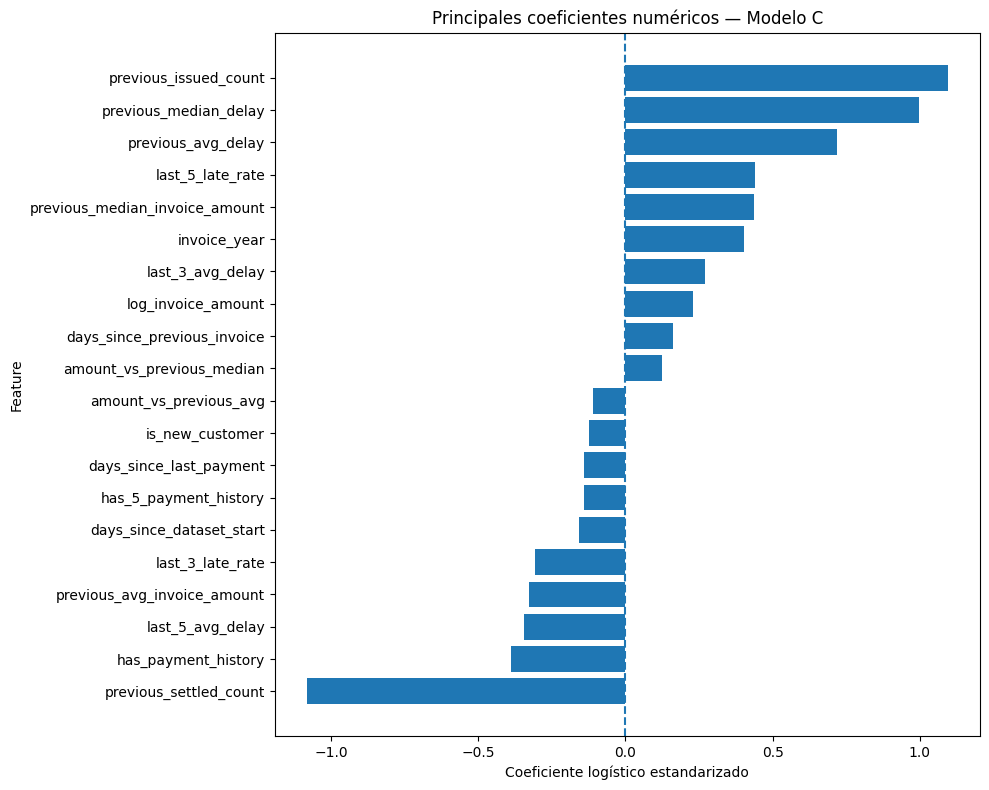

In [29]:
top_positive_plot = (
    numeric_coefficient_df
    .sort_values(
        "coefficient",
        ascending=False
    )
    .head(10)
)

top_negative_plot = (
    numeric_coefficient_df
    .sort_values(
        "coefficient",
        ascending=True
    )
    .head(10)
)

coefficient_plot_df = pd.concat([
    top_negative_plot,
    top_positive_plot,
])

coefficient_plot_df = (
    coefficient_plot_df
    .sort_values(
        "coefficient"
    )
)

fig, ax = plt.subplots(
    figsize=(10, 8)
)

ax.barh(
    coefficient_plot_df["feature"],
    coefficient_plot_df["coefficient"]
)

ax.axvline(
    0,
    linestyle="--"
)

ax.set_title(
    "Principales coeficientes numéricos — Modelo C"
)

ax.set_xlabel(
    "Coeficiente logístico estandarizado"
)

ax.set_ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()

### Lectura del gráfico de coeficientes

Las barras situadas a la derecha de cero representan variables asociadas con un aumento del riesgo estimado de retraso.

Las barras situadas a la izquierda representan variables asociadas con una reducción del riesgo.

La longitud de la barra indica la magnitud del coeficiente dentro de la regresión logística.

Dado que las variables numéricas están estandarizadas, la comparación entre sus coeficientes es más razonable que si se utilizaran sus escalas originales.

No obstante, la presencia de variables correlacionadas puede hacer que el efecto predictivo se reparta entre varias features relacionadas.

Por este motivo no debe interpretarse necesariamente la feature con mayor coeficiente absoluto como la única o principal causa del riesgo.

### Analizar variables categoricas

In [30]:
categorical_coefficient_df[
    [
        "feature",
        "coefficient",
        "odds_ratio",
        "direction"
    ]
].sort_values(
    "coefficient",
    ascending=False
)

,feature,coefficient,odds_ratio,direction
9,invoice_month_12,0.426378,1.531700,Mayor riesgo
13,paperless_bill_PAPER,0.348171,1.416474,Mayor riesgo
15,invoice_month_5,0.339684,1.404504,Mayor riesgo
20,invoice_quarter_3,0.242832,1.274854,Mayor riesgo
21,invoice_weekday_6,0.237600,1.268202,Mayor riesgo
23,invoice_weekday_1,0.194730,1.214983,Mayor riesgo
31,country_code_406,0.134199,1.143620,Mayor riesgo
33,country_code_770,0.124613,1.132711,Mayor riesgo
37,invoice_month_7,0.112003,1.118516,Mayor riesgo
42,country_code_897,0.095026,1.099687,Mayor riesgo


### Visualizacion de variables categoricas

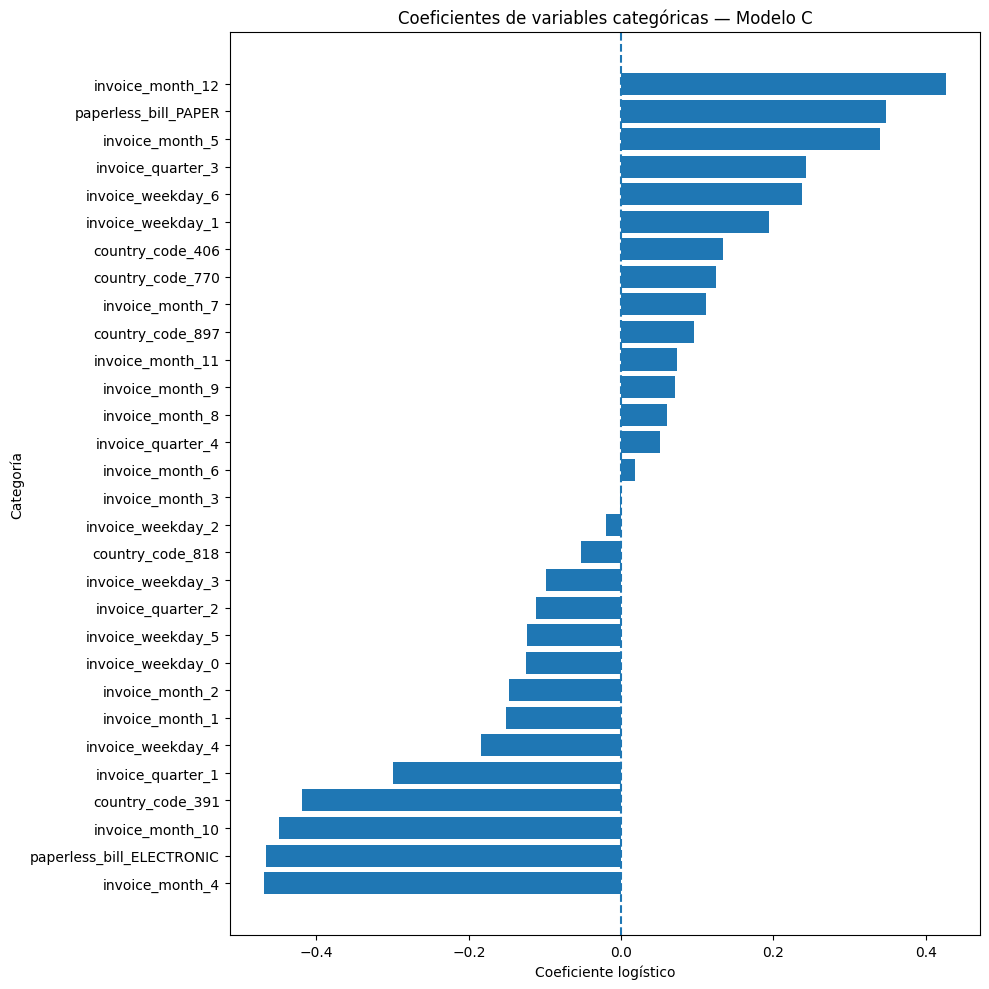

In [31]:
categorical_plot_df = (
    categorical_coefficient_df
    .sort_values(
        "coefficient"
    )
)

fig, ax = plt.subplots(
    figsize=(10, 10)
)

ax.barh(
    categorical_plot_df["feature"],
    categorical_plot_df["coefficient"]
)

ax.axvline(
    0,
    linestyle="--"
)

ax.set_title(
    "Coeficientes de variables categóricas — Modelo C"
)

ax.set_xlabel(
    "Coeficiente logístico"
)

ax.set_ylabel(
    "Categoría"
)

plt.tight_layout()
plt.show()

### Interpretación de las variables categóricas

Las variables categóricas fueron codificadas mediante `OneHotEncoder` sin eliminar una categoría de referencia.

Esto permite reproducir exactamente el modelo baseline, pero implica que los coeficientes categóricos no deben interpretarse como efectos clásicos respecto a una categoría base omitida.

Por ejemplo, los coeficientes de:

- `paperless_bill_PAPER`;
- `paperless_bill_ELECTRONIC`;

pueden utilizarse para observar la dirección relativa aprendida por el modelo, pero no deben presentarse directamente como un odds ratio de PAPER respecto a ELECTRONIC.

Si fuese necesario realizar una interpretación formal de estas categorías, sería preferible construir posteriormente una regresión logística específica con `drop="first"` y una categoría de referencia explícita.

Para este notebook se utilizarán principalmente para comprobar si las asociaciones aprendidas son coherentes con lo observado durante el EDA.

### Extraer escaler para dar contexto a las variables numericas

In [32]:
numeric_transformer_fitted = (
    preprocessor_fitted
    .named_transformers_[
        "numeric"
    ]
)

scaler_fitted = (
    numeric_transformer_fitted
    .named_steps["scaler"]
)

numeric_scale_df = pd.DataFrame({
    "feature": numeric_features,
    "mean_train": scaler_fitted.mean_,
    "std_train": scaler_fitted.scale_,
})

numeric_scale_df.head()

,feature,mean_train,std_train
0,invoice_amount,59.660814,20.494699
1,log_invoice_amount,4.030399,0.427010
2,invoice_year,2012.257126,0.437050
3,is_month_start,0.039558,0.194918
4,is_month_end,0.033741,0.180561


### Desviacion estandar de los coeficientes

In [33]:
numeric_interpretation_df = (
    numeric_coefficient_df
    .merge(
        numeric_scale_df,
        on="feature",
        how="left"
    )
)

numeric_interpretation_df[
    "odds_ratio_per_1_std"
] = np.exp(
    numeric_interpretation_df[
        "coefficient"
    ]
)

numeric_interpretation_df = (
    numeric_interpretation_df
    .sort_values(
        "abs_coefficient",
        ascending=False
    )
)

numeric_interpretation_df[
    [
        "feature",
        "coefficient",
        "odds_ratio_per_1_std",
        "std_train",
    ]
].head(20)

,feature,coefficient,odds_ratio_per_1_std,std_train
0,previous_issued_count,1.095232,2.989875,5.603819
1,previous_settled_count,-1.081617,0.339047,5.505933
2,previous_median_delay,0.996416,2.708556,9.660933
3,previous_avg_delay,0.716932,2.048139,9.515850
4,last_5_late_rate,0.439369,1.551728,0.310083
5,previous_median_invoice_amount,0.436088,1.546644,14.623289
6,invoice_year,0.401569,1.494166,0.437050
7,has_payment_history,-0.388215,0.678266,0.316417
8,last_5_avg_delay,-0.344209,0.708781,8.269855
9,previous_avg_invoice_amount,-0.326579,0.721387,14.512809


### Ejemplo de interpretación de una variable numérica

Supongamos que una feature presenta:

- coeficiente = `0.60`;
- odds ratio = `1.82`;
- desviación estándar en train = `0.20`.

Esto significa que, manteniendo constantes las demás variables, un incremento de aproximadamente una desviación estándar en esa feature está asociado con multiplicar las odds de retraso por aproximadamente `1.82`.

No significa que la probabilidad aumente un 82 %, ya que odds y probabilidad son conceptos diferentes.

Tampoco implica causalidad.

La interpretación correcta es:

> dentro del modelo y condicionado al resto de features, valores superiores de esta variable están asociados con mayor riesgo estimado de retraso.

### Identificar 15 variables numericas mas influyentes

In [34]:
top_numeric_features = (
    numeric_interpretation_df[
        [
            "feature",
            "coefficient",
            "abs_coefficient",
            "odds_ratio_per_1_std",
            "mean_train",
            "std_train",
            "direction",
        ]
    ]
    .head(15)
)

top_numeric_features

,feature,coefficient,abs_coefficient,odds_ratio_per_1_std,mean_train,std_train,direction
0,previous_issued_count,1.095232,1.095232,2.989875,8.485748,5.603819,Mayor riesgo
1,previous_settled_count,-1.081617,1.081617,0.339047,7.567190,5.505933,Menor riesgo
2,previous_median_delay,0.996416,0.996416,2.708556,-2.442118,9.660933,Mayor riesgo
3,previous_avg_delay,0.716932,0.716932,2.048139,-1.942784,9.515850,Mayor riesgo
4,last_5_late_rate,0.439369,0.439369,1.551728,0.311460,0.310083,Mayor riesgo
5,previous_median_invoice_amount,0.436088,0.436088,1.546644,59.719674,14.623289,Mayor riesgo
6,invoice_year,0.401569,0.401569,1.494166,2012.257126,0.437050,Mayor riesgo
7,has_payment_history,-0.388215,0.388215,0.678266,0.887144,0.316417,Menor riesgo
8,last_5_avg_delay,-0.344209,0.344209,0.708781,-2.692728,8.269855,Menor riesgo
9,previous_avg_invoice_amount,-0.326579,0.326579,0.721387,59.878740,14.512809,Menor riesgo


## 5. Validación de coherencia empresarial

Una vez identificadas las variables con mayor coeficiente absoluto, se comprobará si las asociaciones aprendidas son coherentes con el funcionamiento esperado del problema.

En particular se revisará si:

- una tasa histórica elevada de retraso aumenta el riesgo;
- retrasos recientes aumentan el riesgo;
- un retraso medio histórico elevado está asociado con mayor probabilidad de pago tardío;
- clientes con buen comportamiento histórico presentan menor riesgo;
- el importe relativo de la factura aporta información adicional;
- la modalidad de facturación mantiene la relación observada durante el EDA;
- las variables temporales dominan o no el modelo.

El objetivo no es forzar que todas las relaciones coincidan con una hipótesis previa.

Si alguna variable presenta un efecto inesperado se investigará si puede deberse a:

- correlación con otras features;
- redundancia;
- interacción no representada por el modelo lineal;
- cambio temporal;
- características específicas del dataset.

La interpretación se realizará siempre como asociación predictiva y no como causalidad.

### Comprobar peso agregado por familias

In [35]:
feature_family_map = {}

for feature in invoice_features:
    feature_family_map[feature] = (
        "Factura"
    )

for feature in temporal_features:
    feature_family_map[feature] = (
        "Tiempo"
    )

for feature in customer_history_features:
    feature_family_map[feature] = (
        "Histórico cliente"
    )

def get_feature_family(
    transformed_name
):
    clean_name = (
        transformed_name
        .replace(
            "numeric__",
            ""
        )
        .replace(
            "categorical__",
            ""
        )
    )

    # Primero numéricas exactas
    if clean_name in feature_family_map:
        return feature_family_map[
            clean_name
        ]

    # Categóricas codificadas
    for original_feature in (
        categorical_features
    ):
        prefix = (
            original_feature
            + "_"
        )

        if clean_name.startswith(
            prefix
        ):
            return feature_family_map.get(
                original_feature,
                "Otro"
            )

    return "Otro"

### Calcular peso por familia

In [36]:
coefficient_df[
    "family"
] = (
    coefficient_df[
        "feature_transformed"
    ]
    .apply(
        get_feature_family
    )
)

family_importance = (
    coefficient_df
    .groupby("family")
    .agg(
        total_abs_coefficient=(
            "abs_coefficient",
            "sum"
        ),
        mean_abs_coefficient=(
            "abs_coefficient",
            "mean"
        ),
        n_transformed_features=(
            "feature",
            "count"
        ),
    )
    .sort_values(
        "total_abs_coefficient",
        ascending=False
    )
)

family_importance

,total_abs_coefficient,mean_abs_coefficient,n_transformed_features
family,,,
Histórico cliente,7.605193,0.330661,23
Tiempo,4.673618,0.173097,27
Factura,1.918727,0.213192,9


### Visualizacion por familia

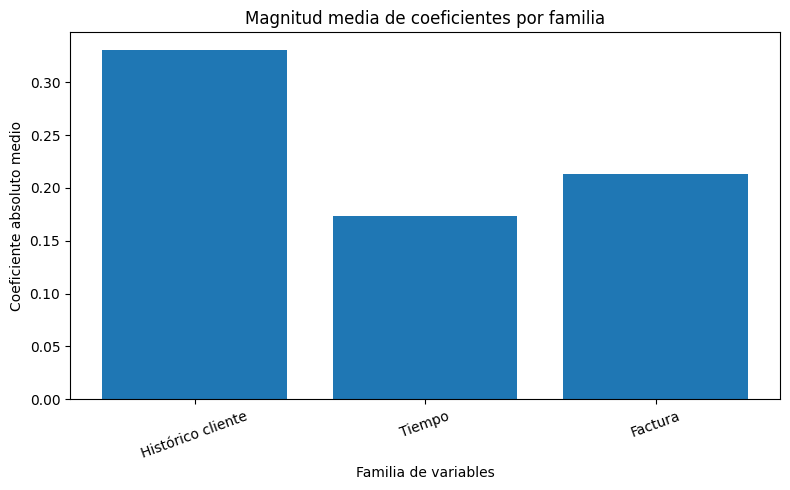

In [37]:
fig, ax = plt.subplots(
    figsize=(8, 5)
)

ax.bar(
    family_importance.index,
    family_importance[
        "mean_abs_coefficient"
    ]
)

ax.set_title(
    "Magnitud media de coeficientes por familia"
)

ax.set_xlabel(
    "Familia de variables"
)

ax.set_ylabel(
    "Coeficiente absoluto medio"
)

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### Interpretación de las familias de variables

La agregación de coeficientes proporciona una visión complementaria del comportamiento del modelo.

El histórico del cliente presenta la mayor magnitud media de coeficientes, por encima de las características de la factura y de las variables temporales.

Este resultado es coherente con la ablación realizada anteriormente, donde la incorporación del histórico produjo el principal salto de rendimiento.

Sin embargo, la suma o media de coeficientes no debe interpretarse como una medida formal de feature importance.

Existen varias limitaciones:

- las familias contienen distinto número de variables;
- algunas variables están altamente correlacionadas;
- las variables categóricas generan varias columnas mediante One-Hot Encoding;
- los coeficientes pueden repartirse entre features redundantes.

Por este motivo, la evidencia principal sobre la importancia del histórico continúa siendo la ablación de features.

El análisis de coeficientes permite complementar esa evidencia indicando qué patrones y asociaciones ha aprendido la regresión logística.

## 6. Permutation Importance

Los coeficientes de la regresión logística permiten estudiar la dirección de las asociaciones aprendidas, pero pueden resultar difíciles de interpretar cuando existen variables correlacionadas.

Como análisis complementario se utilizará `Permutation Importance` sobre el conjunto de validation.

El procedimiento consiste en alterar aleatoriamente los valores de una feature manteniendo constantes las demás y medir cuánto empeora el rendimiento del modelo.

En este caso se utilizará PR-AUC (`average_precision`) como métrica.

Una caída elevada de PR-AUC al permutar una variable indica que el modelo depende de la información contenida en esa feature para realizar sus predicciones.

Este análisis tampoco elimina completamente el problema de las variables correlacionadas: si dos features contienen información similar, permutar una sola puede producir una importancia artificialmente reducida porque la otra sigue aportando información equivalente.

Por tanto, Permutation Importance se utilizará como complemento de:

- la ablación de grupos;
- los coeficientes;
- la interpretación empresarial.

In [38]:
permutation_result = permutation_importance(
    logistic_model_c,
    X_validation,
    y_validation,
    scoring="average_precision",
    n_repeats=30,
    random_state=42,
    n_jobs=-1,
)

permutation_df = pd.DataFrame({
    "feature": X_validation.columns,
    "importance_mean": permutation_result.importances_mean,
    "importance_std": permutation_result.importances_std,
})

permutation_df = (
    permutation_df
    .sort_values(
        "importance_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

permutation_df.head(20)

,feature,importance_mean,importance_std
0,previous_median_delay,0.128766,0.027035
1,previous_settled_count,0.079913,0.015862
2,previous_avg_delay,0.053259,0.020912
3,previous_issued_count,0.039097,0.014369
4,last_5_late_rate,0.036949,0.016771
5,paperless_bill,0.032732,0.012257
6,previous_median_invoice_amount,0.018180,0.010744
7,log_invoice_amount,0.011998,0.006416
8,last_5_avg_delay,0.010626,0.009839
9,last_3_avg_delay,0.009382,0.011201


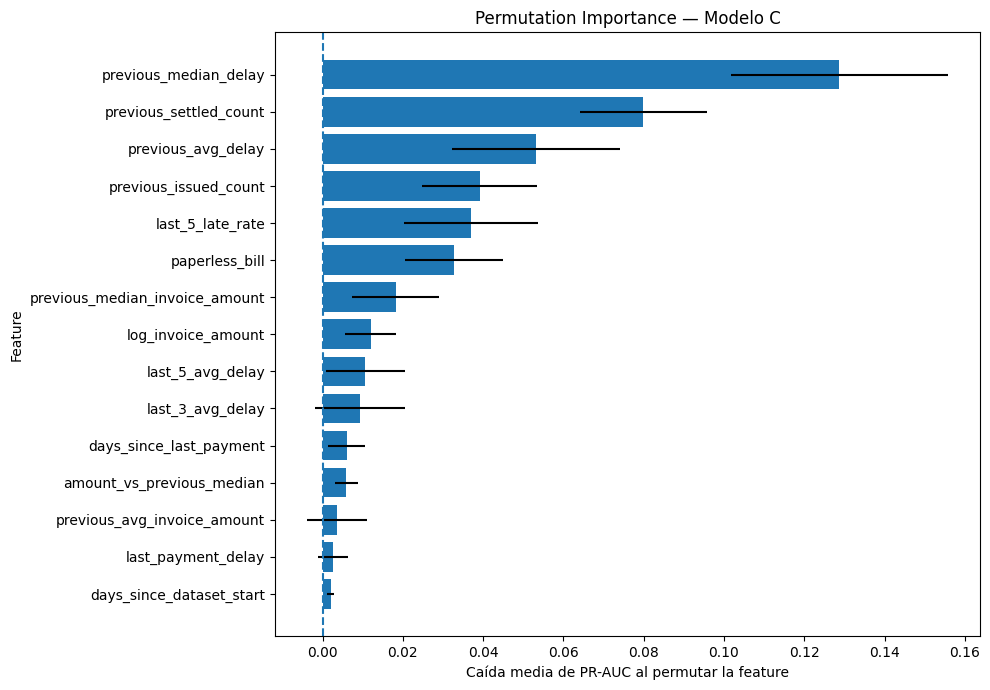

In [39]:
top_permutation = (
    permutation_df
    .head(15)
    .sort_values(
        "importance_mean"
    )
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

ax.barh(
    top_permutation["feature"],
    top_permutation["importance_mean"],
    xerr=top_permutation["importance_std"]
)

ax.axvline(
    0,
    linestyle="--"
)

ax.set_title(
    "Permutation Importance — Modelo C"
)

ax.set_xlabel(
    "Caída media de PR-AUC al permutar la feature"
)

ax.set_ylabel(
    "Feature"
)

plt.tight_layout()
plt.show()

# Conclusiones finales de interpretabilidad

El objetivo de este notebook era comprender qué patrones utiliza la regresión logística seleccionada para estimar el riesgo de retraso y comprobar si su comportamiento es coherente con la lógica empresarial del problema.

El Modelo C ha sido reconstruido correctamente a partir de `gold_invoice_risk.parquet` y reproduce los resultados obtenidos durante la fase de baseline.

Sobre validation obtiene aproximadamente:

- ROC-AUC = 0,904;
- PR-AUC = 0,802;
- Recall = 0,831 con threshold 0,50.

Esto confirma que se está interpretando exactamente el mismo modelo seleccionado anteriormente.

## Importancia del histórico del cliente

Los distintos análisis realizados coinciden en señalar que el histórico del cliente constituye la principal fuente de información predictiva.

Entre las variables numéricas con coeficientes de mayor magnitud aparecen:

- `previous_issued_count`;
- `previous_settled_count`;
- `previous_median_delay`;
- `previous_avg_delay`;
- `last_5_late_rate`.

Las variables relacionadas con los días históricos de retraso presentan asociaciones especialmente coherentes.

Tanto `previous_median_delay` como `previous_avg_delay` tienen coeficientes positivos elevados, indicando que clientes con un comportamiento histórico más retrasado reciben mayor riesgo estimado para nuevas facturas.

Este resultado coincide con la hipótesis empresarial original del proyecto: el comportamiento pasado de pago contiene información relevante para anticipar futuros retrasos.

## Redundancia y multicolinealidad

El análisis también muestra que varios coeficientes no deben interpretarse de forma independiente debido a la elevada correlación entre determinadas features.

El ejemplo más claro aparece entre:

- `previous_issued_count`;
- `previous_settled_count`.

Ambas variables presentan coeficientes elevados y de signo contrario.

Además, se ha comprobado que:

`previous_issued_count - previous_settled_count = open_invoice_count_at_issue`

para el 100 % de las observaciones.

Por tanto, el modelo puede reconstruir indirectamente el número de facturas anteriores todavía abiertas aunque esta variable no forme parte explícitamente del Modelo C.

Esto permite matizar la conclusión de la ablación anterior: las variables adicionales de exposición del Modelo D aportaban poca información incremental, pero el Modelo C ya contiene indirectamente parte de esa información mediante los conteos históricos.

También se observan relaciones redundantes entre:

- media y mediana histórica del retraso;
- media y mediana histórica del importe;
- métricas recientes calculadas sobre las últimas 3 y 5 operaciones;
- variables que representan la evolución temporal.

Como consecuencia, los signos y magnitudes individuales de algunos coeficientes no deben interpretarse como relaciones económicas independientes ni causales.

## Comportamiento reciente

Las variables relacionadas con el comportamiento reciente presentan también señal predictiva.

`last_5_late_rate` aparece entre las variables con mayor coeficiente positivo y también entre las primeras posiciones de Permutation Importance.

Sin embargo, algunas variables calculadas sobre las últimas 3 y 5 operaciones presentan signos diferentes.

Este comportamiento es compatible con la fuerte correlación existente entre estas métricas y confirma que resulta más adecuado interpretar el patrón conjunto que cada coeficiente de forma aislada.

## Modalidad de facturación

La variable `paperless_bill` presenta un comportamiento coherente con lo observado durante el EDA.

Dentro del modelo:

- `PAPER` aparece asociado con mayor riesgo;
- `ELECTRONIC` aparece asociado con menor riesgo.

Permutation Importance también confirma que `paperless_bill` aporta información útil, produciendo una caída media de aproximadamente 0,033 puntos de PR-AUC cuando su información es alterada.

No obstante, esta relación debe interpretarse como asociación predictiva y no como evidencia de que cambiar el formato de una factura provoque una modificación del comportamiento de pago.

## Variables temporales

Las variables temporales tienen una contribución claramente inferior a la del histórico del cliente.

La magnitud media absoluta de los coeficientes por familia es aproximadamente:

- histórico del cliente: 0,331;
- características de factura: 0,213;
- variables temporales: 0,173.

Permutation Importance refuerza esta conclusión.

Por ejemplo, `days_since_dataset_start` produce una caída de PR-AUC cercana a 0,002 cuando se permuta, muy inferior a las variables principales del histórico.

Esto resulta especialmente relevante porque durante el EDA se observó una reducción temporal de la tasa de retraso.

Los resultados indican que la capacidad predictiva del modelo no procede principalmente de aprender esta evolución temporal.

## Permutation Importance

Permutation Importance se ha utilizado como análisis complementario a los coeficientes y a la ablación de grupos.

Las variables cuya alteración produce una mayor pérdida media de PR-AUC son aproximadamente:

1. `previous_median_delay`: 0,129;
2. `previous_settled_count`: 0,080;
3. `previous_avg_delay`: 0,053;
4. `previous_issued_count`: 0,039;
5. `last_5_late_rate`: 0,037;
6. `paperless_bill`: 0,033.

Este resultado confirma nuevamente que el modelo depende principalmente de información relacionada con el historial de pago del cliente.

Algunas features presentan una Permutation Importance muy pequeña aunque conceptualmente estén relacionadas con el riesgo.

Esto no implica necesariamente que sean inútiles, ya que la presencia de variables correlacionadas permite que unas sustituyan parcialmente la información contenida en otras.

Por este motivo, la interpretación final se basa conjuntamente en:

- ablación de grupos de features;
- coeficientes de la regresión logística;
- Permutation Importance;
- coherencia empresarial.

## Limitaciones de la interpretación

Los coeficientes de la regresión logística representan asociaciones condicionadas al resto de variables incluidas en el modelo.

No deben interpretarse como relaciones causales.

Además:

- varias features están fuertemente correlacionadas;
- algunas variables derivan de otras;
- las variables categóricas fueron codificadas sin una categoría base explícita;
- los efectos individuales pueden repartirse entre diferentes columnas.

Por estas razones, el objetivo de la interpretabilidad no es determinar una causa única del retraso, sino comprender qué tipos de información utiliza el modelo para realizar sus predicciones.

## Veredicto

El comportamiento del Modelo C es coherente con la finalidad empresarial del proyecto.

La evidencia conjunta muestra que la mayor parte de la capacidad predictiva procede del **histórico de comportamiento de pago del cliente**, especialmente de la magnitud de sus retrasos anteriores y de la información disponible sobre sus operaciones previas.

Las características de la factura aportan información complementaria, mientras que las variables temporales desempeñan un papel secundario.

La regresión logística proporciona por tanto un baseline no solo competitivo en términos predictivos, sino también suficientemente interpretable para explicar de forma general qué patrones utiliza el sistema para identificar facturas con mayor riesgo.

El notebook de interpretabilidad se considera finalizado.

El conjunto de test permanece completamente reservado y no se ha utilizado durante ningún análisis de interpretabilidad.

El siguiente paso será comparar este baseline con algoritmos de mayor complejidad para determinar si es posible obtener una mejora predictiva suficientemente relevante como para justificar una pérdida parcial de interpretabilidad.